In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Load
df = pd.read_parquet('../data/features.parquet')

# Store 1
store1 = df[df['Store'] == 1].sort_values('Date').copy()
store1 = store1.set_index('Date')

# Train/test split
train = store1[store1.index < '2015-01-01']['Sales']
test = store1[store1.index >= '2015-01-01']['Sales']

print(f"Train: {len(train)} rows")
print(f"Test:  {len(test)} rows")
print(f"\nSales stats (train):")
print(train.describe().round(0))

Train: 606 rows
Test:  175 rows

Sales stats (train):
count     606.0
mean     4826.0
std      1053.0
min      2362.0
25%      4019.0
50%      4704.0
75%      5407.0
max      9528.0
Name: Sales, dtype: float64


ADF Statistic: -4.0895
p-value: 0.0010
Conclusion: Stationary


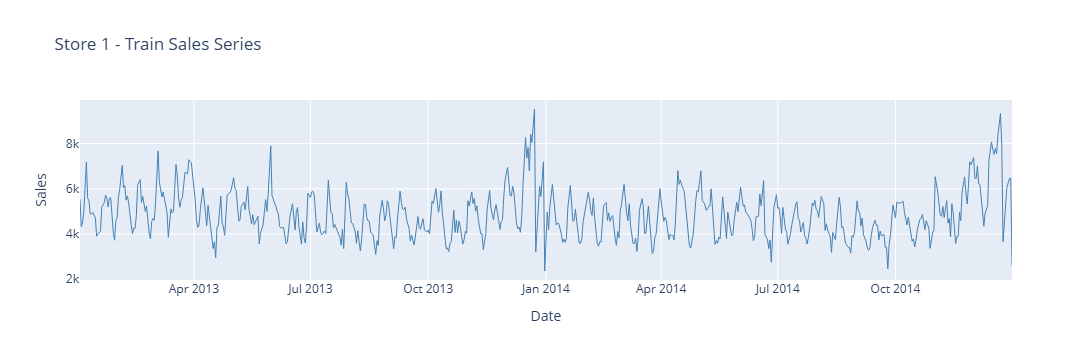

In [2]:
# Augmented Dickey-Fuller test
result = adfuller(train.dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Conclusion: {'Stationary' if result[1] < 0.05 else 'Non-stationary'}")

# Plot train series
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train.values,
    mode='lines',
    line=dict(color='steelblue', width=1),
    name='Sales'
))
fig.update_layout(
    title='Store 1 - Train Sales Series',
    xaxis_title='Date',
    yaxis_title='Sales',
    hovermode='x unified'
)
fig.show()

In [3]:
# Fit SARIMA(1,0,1)(1,1,1,7)
print("Training SARIMA... (1-2 minutes)")

sarima_model = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print("Done.")
print(f"\nAIC: {sarima_fit.aic:.2f}")
print(f"BIC: {sarima_fit.bic:.2f}")

Training SARIMA... (1-2 minutes)
Done.

AIC: 9537.90
BIC: 9559.81


SARIMA Metrics - Store 1 (Test: Jan-Jul 2015)
MAPE: 17.95%
RMSE: 900
MAE:  755


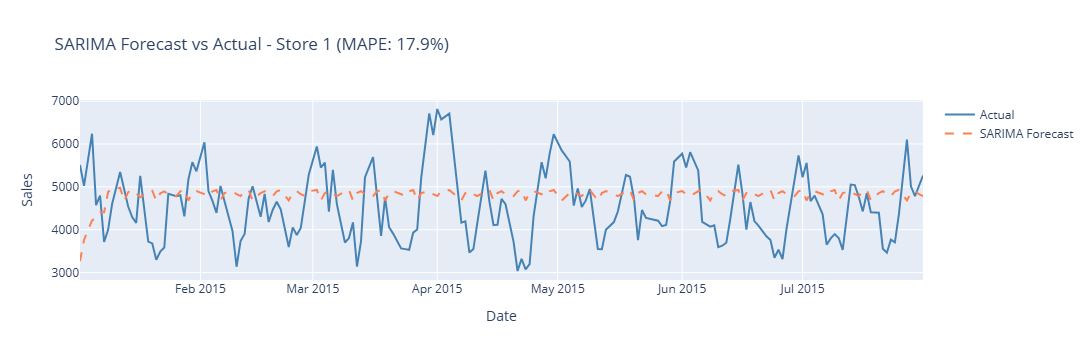

In [4]:
# Forecast
forecast_sarima = sarima_fit.forecast(steps=len(test))
forecast_sarima.index = test.index

# Metrics
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

sarima_mape = mape(test, forecast_sarima)
sarima_rmse = rmse(test, forecast_sarima)
sarima_mae = mae(test, forecast_sarima)

print(f"SARIMA Metrics - Store 1 (Test: Jan-Jul 2015)")
print(f"MAPE: {sarima_mape:.2f}%")
print(f"RMSE: {sarima_rmse:.0f}")
print(f"MAE:  {sarima_mae:.0f}")

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test.index,
    y=test.values,
    mode='lines',
    name='Actual',
    line=dict(color='steelblue', width=2)
))

fig.add_trace(go.Scatter(
    x=forecast_sarima.index,
    y=forecast_sarima.values,
    mode='lines',
    name='SARIMA Forecast',
    line=dict(color='coral', width=2, dash='dash')
))

fig.update_layout(
    title=f'SARIMA Forecast vs Actual - Store 1 (MAPE: {sarima_mape:.1f}%)',
    xaxis_title='Date',
    yaxis_title='Sales',
    hovermode='x unified'
)
fig.show()

In [5]:
import json

sarima_results = {
    'model': 'SARIMA',
    'test_mape': round(sarima_mape, 2),
    'test_rmse': round(sarima_rmse, 0),
    'test_mae': round(sarima_mae, 0),
    'aic': round(sarima_fit.aic, 2),
    'bic': round(sarima_fit.bic, 2)
}

with open('../data/sarima_results.json', 'w') as f:
    json.dump(sarima_results, f)

print("Saved to data/sarima_results.json")
print(f"\nSARIMA Summary - Store 1:")
for k, v in sarima_results.items():
    print(f"  {k}: {v}")

Saved to data/sarima_results.json

SARIMA Summary - Store 1:
  model: SARIMA
  test_mape: 17.95
  test_rmse: 900.0
  test_mae: 755.0
  aic: 9537.9
  bic: 9559.81
